In [1]:
import polars as pl
import tomllib
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import pandas as pd
import numpy as np

from pathlib import Path
from scipy.stats import boxcox, yeojohnson, skew
from sklearn.preprocessing import QuantileTransformer

%matplotlib inline

In [2]:
BASE_DIR = Path(__name__).resolve().parent
DATA_DIR = BASE_DIR / "data" / "processed"

In [3]:
def load_dataset(path:Path) -> pl.DataFrame:
    file_name = "data_raw.parquet"
    return pl.read_parquet(path / file_name)

def info_df(df: pl.DataFrame) -> None:
    n_rows, n_cols = df.shape
    memory_mb = df.estimated_size() / (1024 * 1024)

    null_counts = df.null_count().row(0)
    n_unique = [df[col].n_unique() for col in df.columns]

    print(f"Shape: ({n_rows}, {n_cols})")
    print(f"Approx. Memory Use: {memory_mb:.2f} MB\n")

    max_col_len = max(max([len(c) for c in df.columns]), len("Column"))
    max_dtype_len = max(max([len(str(t)) for t in df.dtypes]), len("Dtype"))

    w_col = max_col_len + 2
    w_dtype = max_dtype_len + 2
    w_null = 14
    w_pct = 11
    w_uniq = 12

    header = (
        f"| {'Column':<{w_col}} | {'Dtype':<{w_dtype}} | "
        f"{'Null Count':>{w_null}} | {'% Null':>{w_pct}} | {'Unique':>{w_uniq}} |"
    )
    separator = f"|{'-' * (len(header) - 2)}|"

    print(header)
    print(separator)

    for col, dtype, nulls, unique in zip(df.columns, df.dtypes, null_counts, n_unique):
        pct_null = (nulls / n_rows) * 100 if n_rows > 0 else 0.0
        print(
            f"| {col:<{w_col}} | {str(dtype):<{w_dtype}} | "
            f"{nulls:>{w_null},} | {pct_null:>{w_pct}.2f}% | {unique:>{w_uniq},} |"
        )

In [4]:
df = load_dataset(DATA_DIR)

In [5]:
df.show()

order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,customer_lat,customer_lon,review_score,payment_types,max_installments,total_payment_value,order_item_id,product_id,price,freight_value,product_category_name,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_city,seller_state,seller_zip_code_prefix,seller_lat,seller_lon
str,str,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,f64,f64,"decimal[38,10]",str,i16,"decimal[38,10]",i16,str,"decimal[38,10]","decimal[38,10]",str,i32,i32,i32,i32,i32,str,str,str,str,f64,f64
"""734a45cad1f49226013e72303953d6…","""delivered""",2017-08-07 16:35:50,2017-08-07 16:55:19,2017-08-08 22:17:59,2017-08-15 15:13:59,2017-08-29 00:00:00,"""cc2c433fef10e158effe8dc9bba501…","""b2d7efad96cd6e0818a695a03507bd…","""belo horizonte""","""MG""","""31930""",-19.864279,-43.908424,5,"""credit_card""",3,102.1,1,"""9926323a78ee2ba9e3b282efce191c…",35,14.1,"""fashion_bolsas_e_acessorios""",1,300,17,17,11,"""8602a61d680a10a82cceeeda0d99ea…","""sao paulo""","""SP""","""1001""",-23.55019,-46.634024
"""a3e9c86c68a63188c0f9e47c68d6ce…","""delivered""",2018-04-08 21:48:15,2018-04-08 22:09:34,2018-04-09 20:04:58,2018-04-17 20:10:51,2018-05-09 00:00:00,"""641408196c4d2b94fb690b7ca0dddb…","""3eb346477783a3af604a5f83064563…","""maceio""","""AL""","""57015""",-9.653908,-35.757675,4,"""voucher""",1,57.85,1,"""38cd38029795797c97b73421fdad08…",35,22.85,"""fashion_bolsas_e_acessorios""",1,350,17,18,17,"""8602a61d680a10a82cceeeda0d99ea…","""sao paulo""","""SP""","""1001""",-23.55019,-46.634024
"""9f3c417d0037cf7d6125ed337ada23…","""delivered""",2018-01-15 14:03:23,2018-01-15 14:15:23,2018-01-15 21:38:52,2018-02-07 19:12:55,2018-02-08 00:00:00,"""c3a9b4092a2b3529d4391cb11f1c45…","""e59c27bf0bef3332139fcd6ad12520…","""araruama""","""RJ""","""28970""",-22.869657,-42.321415,2,"""credit_card, voucher""",1,95.31,1,"""83039266ceedb3640c6dce70f01bf2…",80,15.31,"""fashion_bolsas_e_acessorios""",2,200,20,20,20,"""8602a61d680a10a82cceeeda0d99ea…","""sao paulo""","""SP""","""1001""",-23.55019,-46.634024
"""9a50b650295303f506477ad430996e…","""delivered""",2018-03-09 03:53:22,2018-03-09 04:05:24,2018-03-09 23:28:24,2018-03-13 21:12:23,2018-03-21 00:00:00,"""83393704da3eacab2980fb5c41db4f…","""640e0836427ba779695829b5ea1f6d…","""ferraz de vasconcelos""","""SP""","""8505""",-23.552432,-46.36666,5,"""credit_card""",8,87.43,1,"""83039266ceedb3640c6dce70f01bf2…",80,7.43,"""fashion_bolsas_e_acessorios""",2,200,20,20,20,"""8602a61d680a10a82cceeeda0d99ea…","""sao paulo""","""SP""","""1001""",-23.55019,-46.634024
"""f46e4c3b10d88caacf23b8ee4d674d…","""delivered""",2018-08-02 16:31:11,2018-08-02 17:04:04,2018-08-03 14:12:00,2018-08-09 20:38:41,2018-08-21 00:00:00,"""5e770b11141590d895e35d909ff36c…","""1f3f06e1c78c064d127de4a8326bae…","""rio de janeiro""","""RJ""","""21843""",-22.870893,-43.483302,5,"""credit_card""",1,50.35,1,"""f0c28cf1f8a109a1dc6708397a353e…",35,15.35,"""fashion_bolsas_e_acessorios""",2,100,20,20,20,"""8602a61d680a10a82cceeeda0d99ea…","""sao paulo""","""SP""","""1001""",-23.55019,-46.634024


In [6]:
df.describe()

statistic,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,customer_lat,customer_lon,review_score,payment_types,max_installments,total_payment_value,order_item_id,product_id,price,freight_value,product_category_name,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_city,seller_state,seller_zip_code_prefix,seller_lat,seller_lon
str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,str,f64,f64,f64,str,f64,f64,str,f64,f64,f64,f64,f64,str,str,str,str,f64,f64
"""count""","""113425""","""113425""","""113425""","""113264""","""111457""","""110196""","""113425""","""113425""","""113425""","""113425""","""113425""","""113425""",113119.0,113119.0,112464.0,"""113422""",113422.0,113422.0,112650.0,"""112650""",112650.0,112650.0,"""111047""",111047.0,112632.0,112632.0,112632.0,112632.0,"""112650""","""112650""","""112650""","""112650""",112397.0,112397.0
"""null_count""","""0""","""0""","""0""","""161""","""1968""","""3229""","""0""","""0""","""0""","""0""","""0""","""0""",306.0,306.0,961.0,"""3""",3.0,3.0,775.0,"""775""",775.0,775.0,"""2378""",2378.0,793.0,793.0,793.0,793.0,"""775""","""775""","""775""","""775""",1028.0,1028.0
"""mean""",null,null,"""2017-12-31 12:25:41.686479""","""2017-12-31 22:40:56.664121""","""2018-01-05 02:17:27.942516""","""2018-01-14 13:25:24.023939""","""2018-01-24 08:22:34.875909""",null,null,null,null,null,-21.236147,-46.203868,4.017589,null,3.016611,180.482857,1.197834,null,120.653739,19.99032,null,2.209713,2093.672047,30.153669,16.593766,22.996546,null,null,null,null,-22.797711,-47.235518
"""std""",null,null,null,null,null,null,null,null,null,null,null,null,5.567214,4.03639,1.398415,null,2.802682,273.548227,0.705124,null,183.633928,15.806405,null,1.721438,3751.596884,16.153449,13.443483,11.707268,null,null,null,null,2.697457,2.339961
"""min""","""00010242fe8c5a6d1ba2dd792cb162…","""approved""","""2016-09-04 21:15:19""","""2016-09-15 12:16:38""","""2016-10-08 10:34:01""","""2016-10-11 13:46:32""","""2016-09-30 00:00:00""","""00012a2ce6f8dcda20d059ce984917…","""0000366f3b9a7992bf8c76cfdf3221…","""abadia dos dourados""","""AC""","""1003""",-33.689948,-72.668881,1.0,"""boleto""",0.0,0.0,1.0,"""00066f42aeeb9f3007548bb9d3f33c…",0.85,0.0,"""agro_industria_e_comercio""",1.0,0.0,7.0,2.0,6.0,"""0015a82c2db000af6aaaf3ae2ecb05…","""04482255""","""AC""","""1001""",-32.079231,-67.813284
"""25%""",null,null,"""2017-09-13 11:05:49""","""2017-09-13 20:25:11""","""2017-09-18 20:37:00""","""2017-09-26 20:09:52""","""2017-10-04 00:00:00""",null,null,null,null,null,-23.591282,-48.10994,4.0,null,1.0,65.68,1.0,null,39.9,13.08,null,1.0,300.0,18.0,8.0,15.0,null,null,null,null,-23.607473,-48.829744
"""50%""",null,null,"""2018-01-19 10:37:45""","""2018-01-19 16:59:54""","""2018-01-24 18:44:33""","""2018-02-02 20:58:30""","""2018-02-15 00:00:00""",null,null,null,null,null,-22.930174,-46.634236,5.0,null,2.0,114.4,1.0,null,74.99,16.26,null,1.0,700.0,25.0,13.0,20.0,null,null,null,null,-23.425556,-46.743468
"""75%""",null,null,"""2018-05-04 14:22:16""","""2018-05-04 18:30:23""","""2018-05-08 13:20:00""","""2018-05-15 20:08:51""","""2018-05-25 00:00:00""",null,null,null,null,null,-20.179524,-43.644304,5.0,null,4.0,195.36,1.0,null,134.9,21.15,null,3.0,1800.0,38.0,20.0,30.0,null,null,null,null,-21.757321,-46.518679
"""max""","""fffe41c64501cc87c801fd61db3f62…","""unavailable""","""2018-10-17 17:30:18""","""2018-09-03 17:40:06""","""2018-09-11 19:48:28""","""2018-10-17 13:22:46""","""2018-11-12 00:00:00""","""ffffe8b65bbe3087b653a978c870db…","""ffffd2657e2aad2907e67c3e9daecb…","""zortea""","""TO""","""99990""",42.184003,-8.723762,5.0,"""voucher""",24.0,13664.08,21.0,"""fffe9eeff12fcbd74a2f2b007dde0c…",6735.0,409.68,"""utilidades_domesticas""",20.0,40425.0,105.0,105.0,118.0,"""ffff564a4f9085cd26

In [75]:
info_df(df)

Shape: (113425, 34)
Approx. Memory Use: 42.10 MB

| Column                          | Dtype                                      |     Null Count |      % Null |       Unique |
|----------------------------------------------------------------------------------------------------------------------------|
| order_id                        | String                                     |              0 |        0.00% |       99,441 |
| order_status                    | String                                     |              0 |        0.00% |            8 |
| order_purchase_timestamp        | Datetime(time_unit='us', time_zone=None)   |              0 |        0.00% |       98,875 |
| order_approved_at               | Datetime(time_unit='us', time_zone=None)   |            161 |        0.14% |       90,734 |
| order_delivered_carrier_date    | Datetime(time_unit='us', time_zone=None)   |          1,968 |        1.74% |       81,019 |
| order_delivered_customer_date   | Datetime(time_unit='

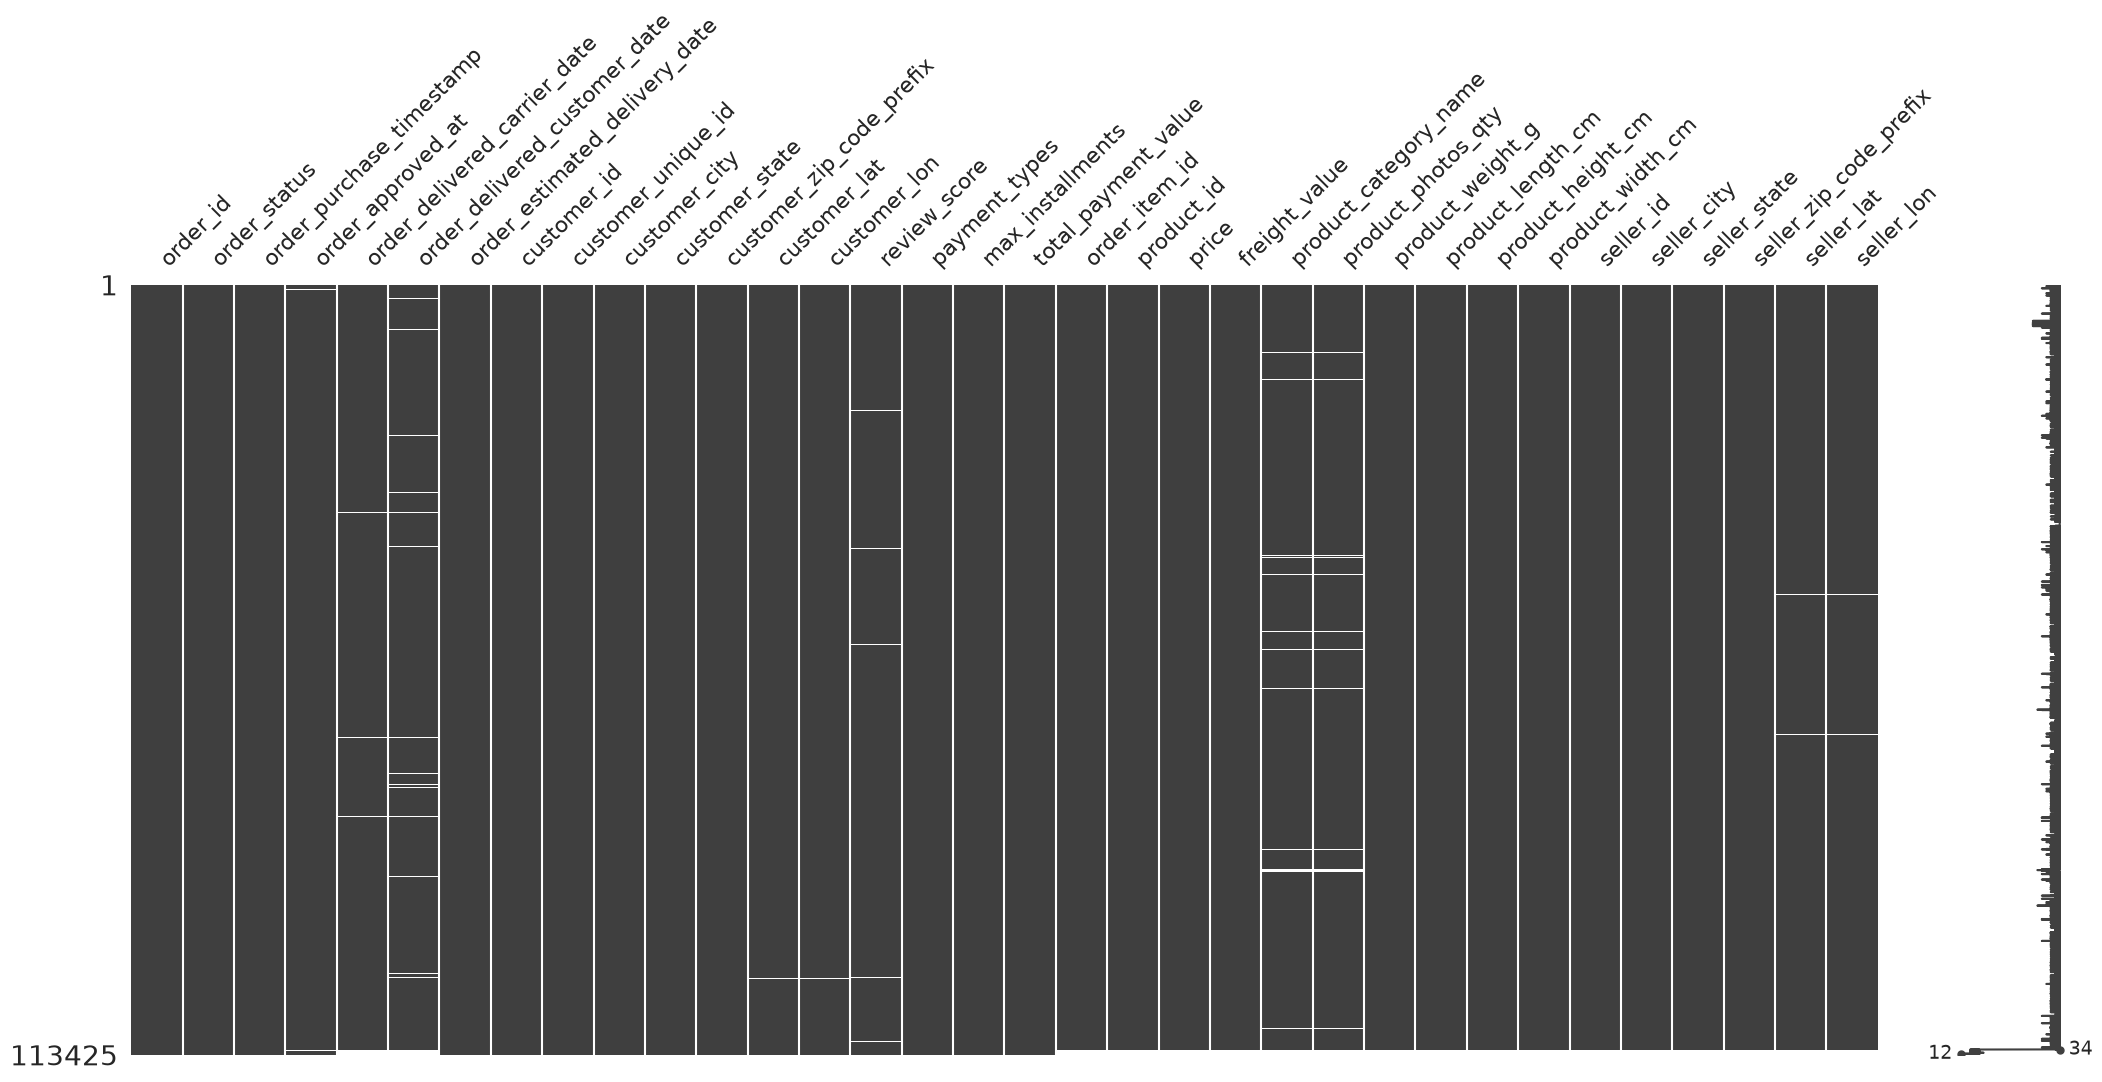

In [76]:
msno.matrix(df.to_pandas())
plt.show()

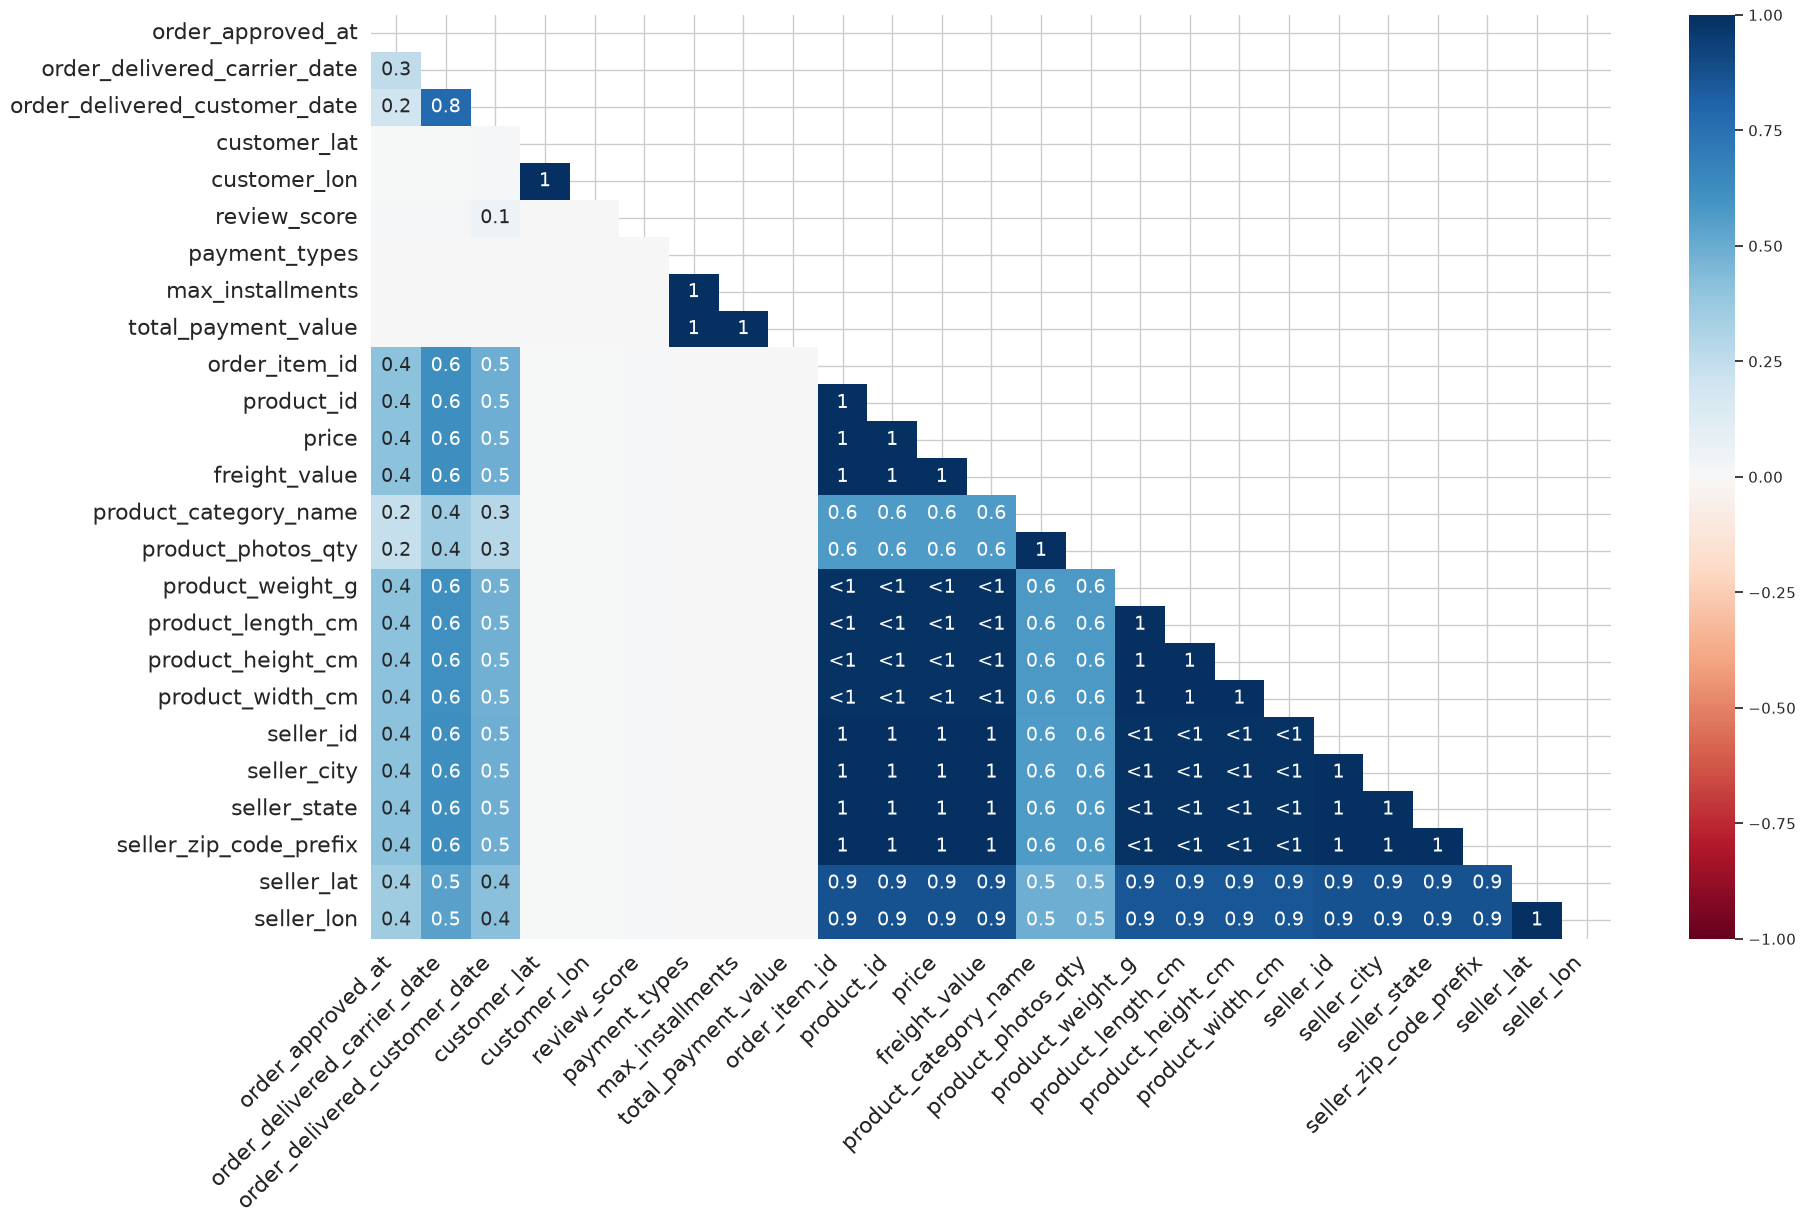

In [60]:
msno.heatmap(df.to_pandas())
plt.show()

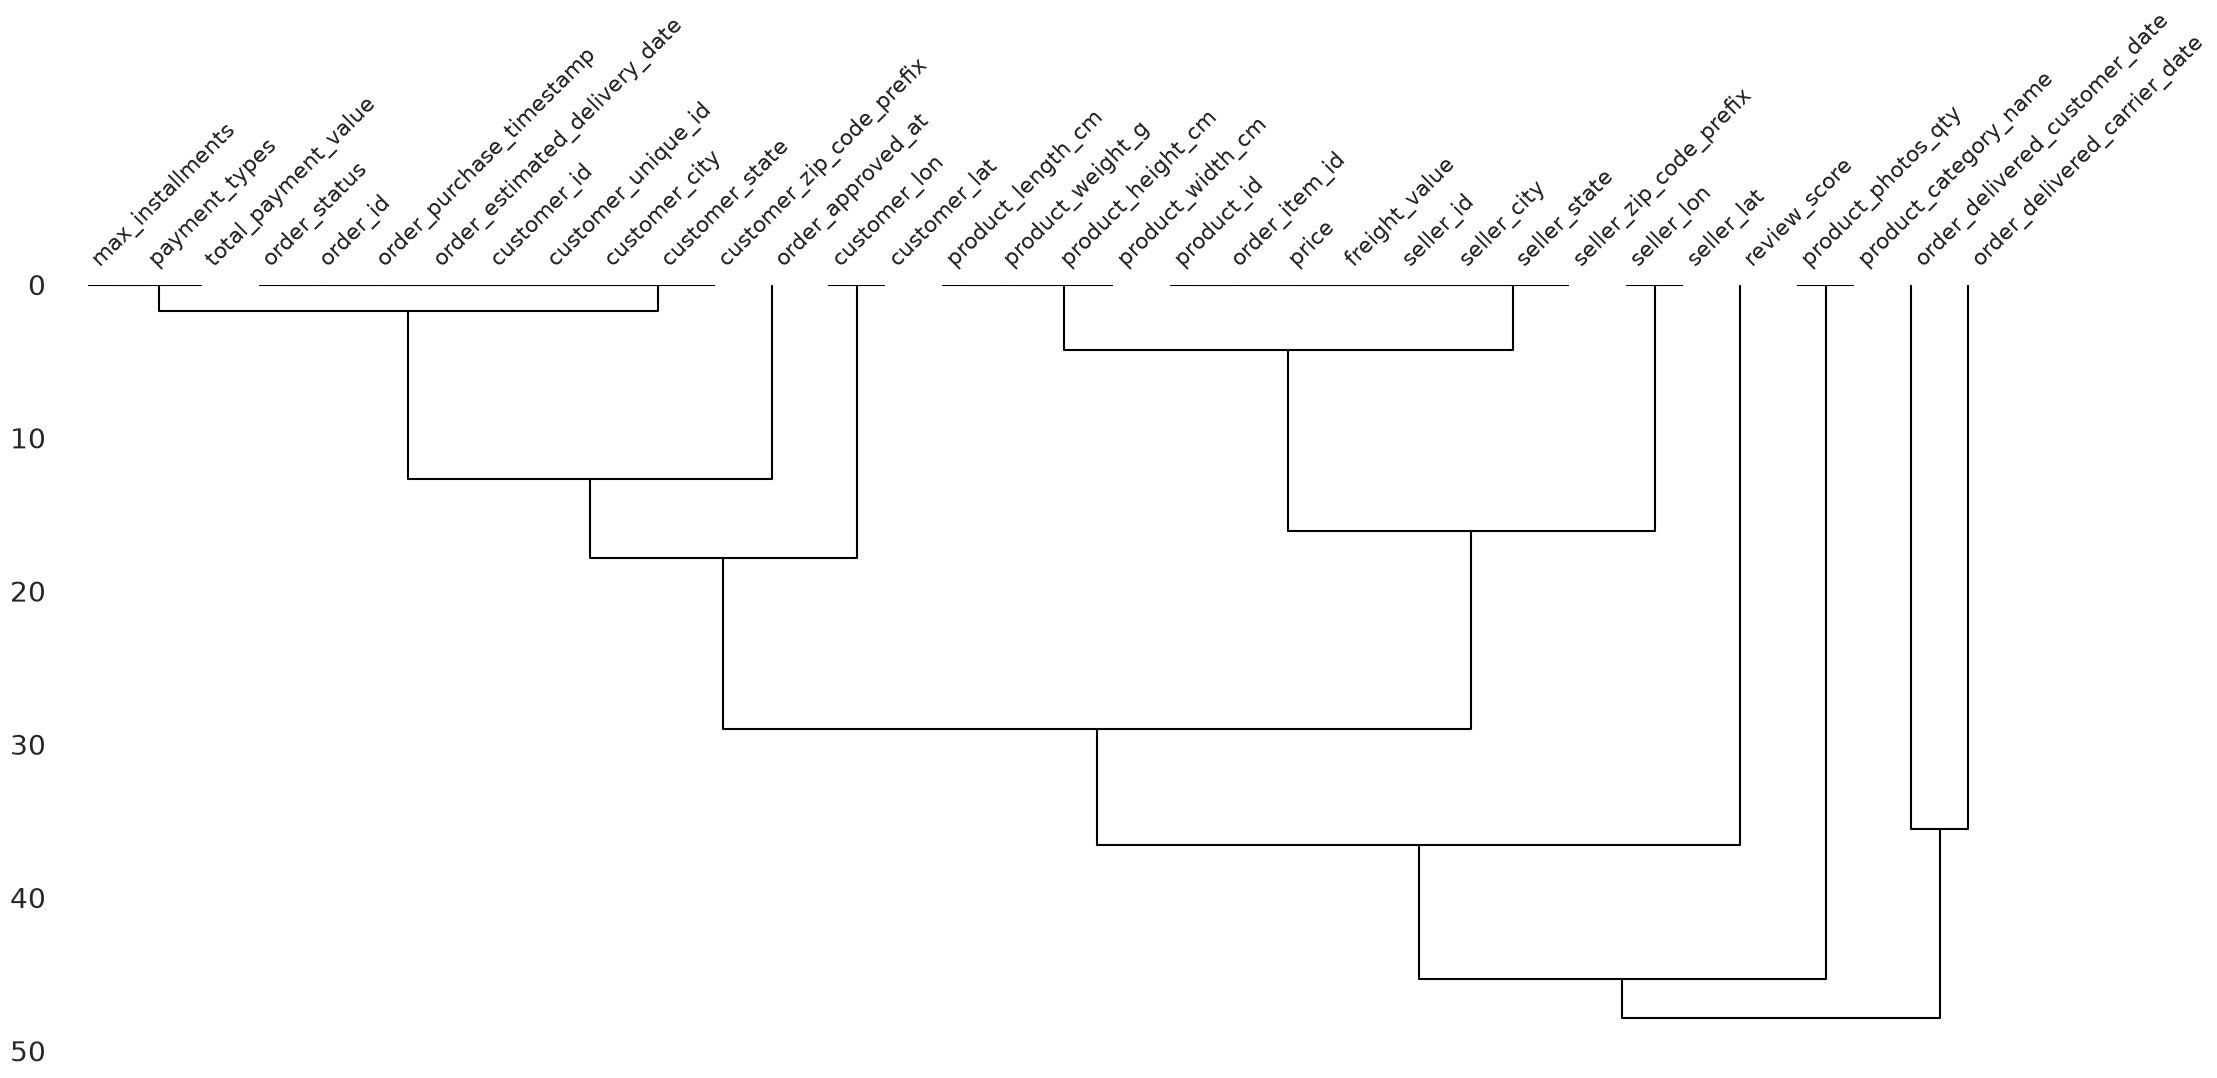

In [61]:
msno.dendrogram(df.to_pandas())
plt.show()

In [7]:
customer_geo_check = (
    df.group_by("customer_city", "customer_state")
    .agg([
        pl.len().alias("total_orders"),
        pl.col("customer_lat").null_count().alias("null_coords_count"),
        pl.col("customer_lat").count().alias("valid_coords_count")
    ])
    .filter(pl.col("null_coords_count") > 0) # Filtrar solo ciudades con nulos
    .with_columns(
        # Indica si la ciudad tiene al menos un dato válido para calcular el centroide
        (pl.col("valid_coords_count") > 0).alias("can_impute_internally")
    )
)

print("--- Diagnóstico de Ciudades con Nulos (Clientes) ---")
print(customer_geo_check)

# Resumen numérico directo:
total_cities_with_nulls = customer_geo_check.height
viable_cities = customer_geo_check.filter(pl.col("can_impute_internally")).height
orphan_cities = customer_geo_check.filter(~pl.col("can_impute_internally")).height

print(f"\nTotal of Customers Cities with at least one Null: {total_cities_with_nulls}")
print(f"Customers with geolocation info avaible to impute: {viable_cities}")
print(f"Orpahn customers (no avaible imputation data): {orphan_cities}")

--- Diagnóstico de Ciudades con Nulos (Clientes) ---
shape: (86, 6)
┌────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬───────────────┐
│ customer_city  ┆ customer_state ┆ total_orders ┆ null_coords_co ┆ valid_coords_c ┆ can_impute_in │
│ ---            ┆ ---            ┆ ---          ┆ unt            ┆ ount           ┆ ternally      │
│ str            ┆ str            ┆ u32          ┆ ---            ┆ ---            ┆ ---           │
│                ┆                ┆              ┆ u32            ┆ u32            ┆ bool          │
╞════════════════╪════════════════╪══════════════╪════════════════╪════════════════╪═══════════════╡
│ glaura         ┆ MG             ┆ 1            ┆ 1              ┆ 0              ┆ false         │
│ gurupi         ┆ TO             ┆ 27           ┆ 1              ┆ 26             ┆ true          │
│ maioba         ┆ MA             ┆ 3            ┆ 3              ┆ 0              ┆ false         │
│ itu            ┆ SP  

In [8]:
seller_geo_check = (
    df.group_by("seller_city", "seller_state")
    .agg([
        pl.len().alias("total_items"),
        pl.col("seller_lat").null_count().alias("null_coords_count"),
        pl.col("seller_lat").count().alias("valid_coords_count")
    ])
    .filter(pl.col("null_coords_count") > 0)
    .with_columns(
        (pl.col("valid_coords_count") > 0).alias("can_impute_internally")
    )
)

print("NULL Diagnosis for Sellers")
print(seller_geo_check)

# Resumen numérico
total_seller_cities_nulls = seller_geo_check.height
viable_seller_cities = seller_geo_check.filter(pl.col("can_impute_internally")).height
orphan_seller_cities = seller_geo_check.filter(~pl.col("can_impute_internally")).height

print(f"\nTotal of Seller Cities with at least one Null: {total_seller_cities_nulls}")
print(f"Cities with geolocation info avaible to impute: {viable_seller_cities}")
print(f"Orpahn cities (no avaible imputation data): {orphan_seller_cities}")

NULL Diagnosis for Sellers
shape: (7, 6)
┌─────────────────┬──────────────┬─────────────┬─────────────────┬────────────────┬────────────────┐
│ seller_city     ┆ seller_state ┆ total_items ┆ null_coords_cou ┆ valid_coords_c ┆ can_impute_int │
│ ---             ┆ ---          ┆ ---         ┆ nt              ┆ ount           ┆ ernally        │
│ str             ┆ str          ┆ u32         ┆ ---             ┆ ---            ┆ ---            │
│                 ┆              ┆             ┆ u32             ┆ u32            ┆ bool           │
╞═════════════════╪══════════════╪═════════════╪═════════════════╪════════════════╪════════════════╡
│ null            ┆ null         ┆ 775         ┆ 775             ┆ 0              ┆ false          │
│ curitiba        ┆ PR           ┆ 2944        ┆ 9               ┆ 2935           ┆ true           │
│ porto alegre    ┆ RS           ┆ 799         ┆ 2               ┆ 797            ┆ true           │
│ sao paulo       ┆ SP           ┆ 27983       ┆ 1

In [9]:
LAT_MIN, LAT_MAX = -33.75, 5.27
LON_MIN, LON_MAX = -73.98, -34.79

# 2. Expresiones de auditoría lógica
logical_checks = {
    # Fechas
    "err_approved_before_purchase": (
        pl.col("order_approved_at") < pl.col("order_purchase_timestamp")
    ),
    "err_carrier_before_approval": (
        pl.col("order_delivered_carrier_date") < pl.col("order_approved_at")
    ),
    "err_customer_before_carrier": (
        pl.col("order_delivered_customer_date") < pl.col("order_delivered_carrier_date")
    ),
    "err_customer_before_purchase": (
        pl.col("order_delivered_customer_date") < pl.col("order_purchase_timestamp")
    ),
    # Financieros
    "err_price_non_positive": pl.col("price") <= 0,
    "err_freight_negative": pl.col("freight_value") < 0,
    # Físicos
    "err_zero_weight": (
        (pl.col("order_status") == "delivered") & (pl.col("product_weight_g") == 0)
    ),
    "err_zero_volume": (
        (pl.col("order_status") == "delivered") & 
        ((pl.col("product_length_cm") * pl.col("product_height_cm") * pl.col("product_width_cm")) == 0)
    ),
    # Geográficos
    "err_customer_geo_out_of_bounds": (
        ~pl.col("customer_lat").is_between(LAT_MIN, LAT_MAX) | 
        ~pl.col("customer_lon").is_between(LON_MIN, LON_MAX)
    ),
    "err_seller_geo_out_of_bounds": (
        ~pl.col("seller_lat").is_between(LAT_MIN, LAT_MAX) | 
        ~pl.col("seller_lon").is_between(LON_MIN, LON_MAX)
    ),
}

# 3. Ejecutar conteo de violaciones
audit_summary = df.select([
    expr.fill_null(False).sum().alias(check_name)
    for check_name, expr in logical_checks.items()
])

# Convertir a formato de tabla legible
audit_df = audit_summary.to_pandas().T.reset_index()
audit_df.columns = ["Invalid Logic Data", "Invalid_Records"]
audit_df["percent"] = (audit_df["Invalid_Records"] / len(df)) * 100

print(audit_df.to_string(index=False))

            Invalid Logic Data  Invalid_Records  percent
  err_approved_before_purchase                0 0.000000
   err_carrier_before_approval             1551 1.367423
   err_customer_before_carrier               50 0.044082
  err_customer_before_purchase                0 0.000000
        err_price_non_positive                0 0.000000
          err_freight_negative                0 0.000000
               err_zero_weight                8 0.007053
               err_zero_volume                0 0.000000
err_customer_geo_out_of_bounds               10 0.008816
  err_seller_geo_out_of_bounds                0 0.000000


In [10]:
print(f"Num of Records before remove inconsistencies: {len(df)}")

df = df.with_columns(
    pl.when(pl.col("product_weight_g") > 0)
    .then(pl.col("product_weight_g"))
    .otherwise(
        pl.col("product_weight_g")
        .median()
        .over("product_category_name")
    )
    .alias("product_weight_g")
)

df = df.with_columns([
    pl.when(pl.col("customer_lat").is_between(LAT_MIN, LAT_MAX))
    .then(pl.col("customer_lat"))
    .otherwise(None)
    .alias("customer_lat"),
    
    pl.when(pl.col("customer_lon").is_between(LON_MIN, LON_MAX))
    .then(pl.col("customer_lon"))
    .otherwise(None)
    .alias("customer_lon")
])

df = df.filter(
    (pl.col("order_delivered_customer_date") >= pl.col("order_delivered_carrier_date")) |
    pl.col("order_delivered_customer_date").is_null() |
    pl.col("order_delivered_carrier_date").is_null()
).filter(
    (pl.col("order_delivered_carrier_date") >= pl.col("order_approved_at")) |
    pl.col("order_delivered_carrier_date").is_null() |
    pl.col("order_approved_at").is_null()
)

print(f"Records left: {len(df)}")

Num of Records before remove inconsistencies: 113425
Records left: 111824


In [11]:
df = df.with_columns([
    # Customers
    pl.col("customer_lat")
    .fill_null(pl.col("customer_lat").mean().over("customer_city"))
    .fill_null(pl.col("customer_lat").mean().over("customer_state")),

    pl.col("customer_lon")
    .fill_null(pl.col("customer_lon").mean().over("customer_city"))
    .fill_null(pl.col("customer_lon").mean().over("customer_state")),

    # Sellers
    pl.col("seller_lat")
    .fill_null(pl.col("seller_lat").mean().over("seller_city"))
    .fill_null(pl.col("seller_lat").mean().over("seller_state")),

    pl.col("seller_lon")
    .fill_null(pl.col("seller_lon").mean().over("seller_city"))
    .fill_null(pl.col("seller_lon").mean().over("seller_state")),
])

# Null remaining
geo_nulls = df.select([
    pl.col("customer_lat").null_count().alias("null_customer_lat"),
    pl.col("seller_lat").null_count().alias("null_seller_lat"),
]).row(0)

print(f"Customers Null Count: {geo_nulls[0]}")
print(f"Sellers Null Count: {geo_nulls[1]}")

Customers Null Count: 0
Sellers Null Count: 775


In [12]:
df = df.with_columns([
    # Reviews
    pl.col("review_score").is_null().cast(pl.Int8).alias("is_missing_review"),
    pl.col("review_score").fill_null(0.0),
    # Product info
    pl.col("product_weight_g").is_null().cast(pl.Int8).alias("is_missing_product_specs"),
    pl.col("product_weight_g").fill_null(-1.0),
    pl.col("product_length_cm").fill_null(-1.0),
    pl.col("product_height_cm").fill_null(-1.0),
    pl.col("product_width_cm").fill_null(-1.0),
    pl.col("product_photos_qty").fill_null(0),

    # Products Category
    pl.col("product_category_name").fill_null("UNKNOWN"),

    # Payments
    pl.col("payment_types").fill_null("UNKNOWN"),
    pl.col("max_installments").fill_null(0),
    pl.col("total_payment_value").fill_null(0.0),
])

In [13]:
null_summary = df.select([
    pl.col(col).null_count().alias(col) 
    for col in df.columns 
    if not col.endswith(("_date", "_timestamp", "_at"))
])

print(null_summary.to_pandas().T.rename(columns={0: "null_count"}))

                          null_count
order_id                           0
order_status                       0
customer_id                        0
customer_unique_id                 0
customer_city                      0
customer_state                     0
customer_zip_code_prefix           0
customer_lat                       0
customer_lon                       0
review_score                       0
payment_types                      0
max_installments                   0
total_payment_value                0
order_item_id                    775
product_id                       775
price                            775
freight_value                    775
product_category_name              0
product_photos_qty                 0
product_weight_g                   0
product_length_cm                  0
product_height_cm                  0
product_width_cm                   0
seller_id                        775
seller_city                      775
seller_state                     775
s

In [14]:
df = df.filter(pl.col("seller_id").is_not_null())

In [15]:
info_df(df)

Shape: (111049, 36)
Approx. Memory Use: 41.30 MB

| Column                          | Dtype                                      |     Null Count |      % Null |       Unique |
|----------------------------------------------------------------------------------------------------------------------------|
| order_id                        | String                                     |              0 |        0.00% |       97,284 |
| order_status                    | String                                     |              0 |        0.00% |            7 |
| order_purchase_timestamp        | Datetime(time_unit='us', time_zone=None)   |              0 |        0.00% |       96,738 |
| order_approved_at               | Datetime(time_unit='us', time_zone=None)   |             15 |        0.01% |       89,204 |
| order_delivered_carrier_date    | Datetime(time_unit='us', time_zone=None)   |          1,194 |        1.08% |       80,140 |
| order_delivered_customer_date   | Datetime(time_unit='

In [16]:
df = df.with_columns([
    # Time of Delivery
    ((pl.col("order_delivered_customer_date") - pl.col("order_purchase_timestamp"))
     .dt.total_seconds() / 86400.0)
    .alias("delivery_time_days"),

    # After/before estimated delivery date
    ((pl.col("order_delivered_customer_date") - pl.col("order_estimated_delivery_date"))
     .dt.total_seconds() / 86400.0)
    .alias("delay_vs_estimated_days"),

    # Payment Approval time
    ((pl.col("order_approved_at") - pl.col("order_purchase_timestamp"))
     .dt.total_seconds() / 3600.0)
    .alias("payment_approval_time_hours"),

    # Product Volume
    (pl.col("product_length_cm") * pl.col("product_height_cm") * pl.col("product_width_cm"))
    .alias("product_volume_cm3"),

    # Freight Ratio
    (pl.col("freight_value") / (pl.col("price") + pl.col("freight_value") + 1e-5))
    .alias("freight_ratio")
])

In [17]:
def add_haversine_distance(df: pl.DataFrame) -> pl.DataFrame:
    """Calculate the Haversine distance in Kilometers between customers and sellers."""
    R = 6371.0

    lat1 = pl.col("seller_lat").radians()
    lon1 = pl.col("seller_lon").radians()
    lat2 = pl.col("customer_lat").radians()
    lon2 = pl.col("customer_lon").radians()

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine Formula
    a = (dlat / 2).sin() ** 2 + lat1.cos() * lat2.cos() * (dlon / 2).sin() ** 2
    c = 2 * a.sqrt().arcsin()

    return df.with_columns((R * c).alias("distance_km"))

df = add_haversine_distance(df)

In [18]:
df = df.with_columns([
    pl.col("price").cast(pl.Float64),
    pl.col("freight_value").cast(pl.Float64),
])

In [43]:
category_mapping = {
    # Health, Beauty & Wellness
    "beleza_saude": "health_beauty_wellness",
    "perfumaria": "health_beauty_wellness",
    "fraldas_higiene": "health_beauty_wellness",
    
    # Home, Furniture & Kitchen
    "cama_mesa_banho": "home_furniture_decor",
    "utilidades_domesticas": "home_furniture_decor",
    "moveis_decoracao": "home_furniture_decor",
    "moveis_escritorio": "home_furniture_decor",
    "moveis_sala": "home_furniture_decor",
    "moveis_cozinha_area_de_servico_jantar_e_jardim": "home_furniture_decor",
    "moveis_quarto": "home_furniture_decor",
    "moveis_colchao_e_estofado": "home_furniture_decor",
    "casa_conforto": "home_furniture_decor",
    "casa_conforto_2": "home_furniture_decor",
    "la_cuisine": "home_furniture_decor",
    "portateis_casa_forno_e_cafe": "home_furniture_decor",
    "portateis_cozinha_e_preparadores_de_alimentos": "home_furniture_decor",

    # Tech, Electronics & Appliances
    "informatica_acessorios": "tech_electronics_appliances",
    "telefonia": "tech_electronics_appliances",
    "eletronicos": "tech_electronics_appliances",
    "audio": "tech_electronics_appliances",
    "eletrodomesticos": "tech_electronics_appliances",
    "eletrodomesticos_2": "tech_electronics_appliances",
    "eletroportateis": "tech_electronics_appliances",
    "telefonia_fixa": "tech_electronics_appliances",
    "consoles_games": "tech_electronics_appliances",
    "pcs": "tech_electronics_appliances",
    "pc_gamer": "tech_electronics_appliances",
    "tablets_impressao_imagem": "tech_electronics_appliances",
    "cine_foto": "tech_electronics_appliances",
    "climatizacao": "tech_electronics_appliances",

    # Fashion, Apparel & Accessories
    "fashion_bolsas_e_acessorios": "fashion_apparel_accessories",
    "relogios_presentes": "fashion_apparel_accessories",
    "malas_acessorios": "fashion_apparel_accessories",
    "fashion_calcados": "fashion_apparel_accessories",
    "fashion_roupa_masculina": "fashion_apparel_accessories",
    "fashion_roupa_feminina": "fashion_apparel_accessories",
    "fashion_underwear_e_moda_praia": "fashion_apparel_accessories",
    "fashion_esporte": "fashion_apparel_accessories",
    "fashion_roupa_infanto_juvenil": "fashion_apparel_accessories",

    # Sports, Leisure, Baby & Toys
    "esporte_lazer": "sports_leisure_toys",
    "brinquedos": "sports_leisure_toys",
    "bebes": "sports_leisure_toys",
    "artigos_de_festas": "sports_leisure_toys",
    "artigos_de_natal": "sports_leisure_toys",

    # Construction, Tools & Auto
    "ferramentas_jardim": "construction_tools_auto",
    "automotivo": "construction_tools_auto",
    "casa_construcao": "construction_tools_auto",
    "construcao_ferramentas_construcao": "construction_tools_auto",
    "construcao_ferramentas_iluminacao": "construction_tools_auto",
    "construcao_ferramentas_jardim": "construction_tools_auto",
    "construcao_ferramentas_seguranca": "construction_tools_auto",
    "construcao_ferramentas_ferramentas": "construction_tools_auto",
    "sinalizacao_e_seguranca": "construction_tools_auto",

    # Books, Media & Entertainment
    "livros_interesse_geral": "books_media_entertainment",
    "livros_tecnicos": "books_media_entertainment",
    "livros_importados": "books_media_entertainment",
    "instrumentos_musicais": "books_media_entertainment",
    "cds_dvds_musicais": "books_media_entertainment",
    "dvds_blu_ray": "books_media_entertainment",
    "musica": "books_media_entertainment",

    # Food, Beverage & Pets
    "pet_shop": "food_beverage_groceries",
    "alimentos": "food_beverage_groceries",
    "bebidas": "food_beverage_groceries",
    "alimentos_bebidas": "food_beverage_groceries",

    # B2B, Office, Industry & Services
    "papelaria": "b2b_office_industry",
    "industria_comercio_e_negocios": "b2b_office_industry",
    "agro_industria_e_comercio": "b2b_office_industry",
    "seguros_e_servicos": "b2b_office_industry",

    # Other & Specialty
    "cool_stuff": "other_specialty",
    "artes": "other_specialty",
    "artes_e_artesanato": "other_specialty",
    "flores": "other_specialty",
    "market_place": "other_specialty",
    "UNKNOWN": "other_specialty",
}

# Lista ordenada de los 10 niveles macro
macro_categories = [
    "health_beauty_wellness",
    "home_furniture_decor",
    "tech_electronics_appliances",
    "fashion_apparel_accessories",
    "sports_leisure_toys",
    "construction_tools_auto",
    "books_media_entertainment",
    "food_beverage_groceries",
    "b2b_office_industry",
    "other_specialty",
]

# Product Categories Codes
cat_to_code = {cat: i for i, cat in enumerate(macro_categories)}

df = df.with_columns([
    pl.col("product_category_name")
    .replace_strict(category_mapping, default="other_specialty")
    .alias("product_category_macro"),
    
    pl.col("order_purchase_timestamp").dt.weekday().cast(pl.Float64).alias("purchase_dayofweek"),
    pl.col("order_purchase_timestamp").dt.hour().cast(pl.Float64).alias("purchase_hour"),
]).with_columns([
    pl.col("product_category_macro")
    .replace_strict(cat_to_code, default=cat_to_code["other_specialty"])
    .cast(pl.Float64)
    .alias("product_category_code")
])

In [44]:
info_df(df)

Shape: (111049, 46)
Approx. Memory Use: 49.60 MB

| Column                          | Dtype                                      |     Null Count |      % Null |       Unique |
|----------------------------------------------------------------------------------------------------------------------------|
| order_id                        | String                                     |              0 |        0.00% |       97,284 |
| order_status                    | String                                     |              0 |        0.00% |            7 |
| order_purchase_timestamp        | Datetime(time_unit='us', time_zone=None)   |              0 |        0.00% |       96,738 |
| order_approved_at               | Datetime(time_unit='us', time_zone=None)   |             15 |        0.01% |       89,204 |
| order_delivered_carrier_date    | Datetime(time_unit='us', time_zone=None)   |          1,194 |        1.08% |       80,140 |
| order_delivered_customer_date   | Datetime(time_unit='

In [45]:
numeric_schema = [
    col for col, dtype in df.schema.items()
    if dtype in [pl.Float32, pl.Float64, pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.Decimal]
]
exclude_cols = ["customer_zip_code_prefix", "seller_zip_code_prefix", "is_missing_product_specs", "is_missing_review", "order_item_id"]
numeric_cols = [col for col in numeric_schema if col not in exclude_cols]

df_num = df.select(numeric_cols).to_pandas()

for col in df_num.select_dtypes(include=['object']).columns:
    df_num[col] = df_num[col].astype(float)

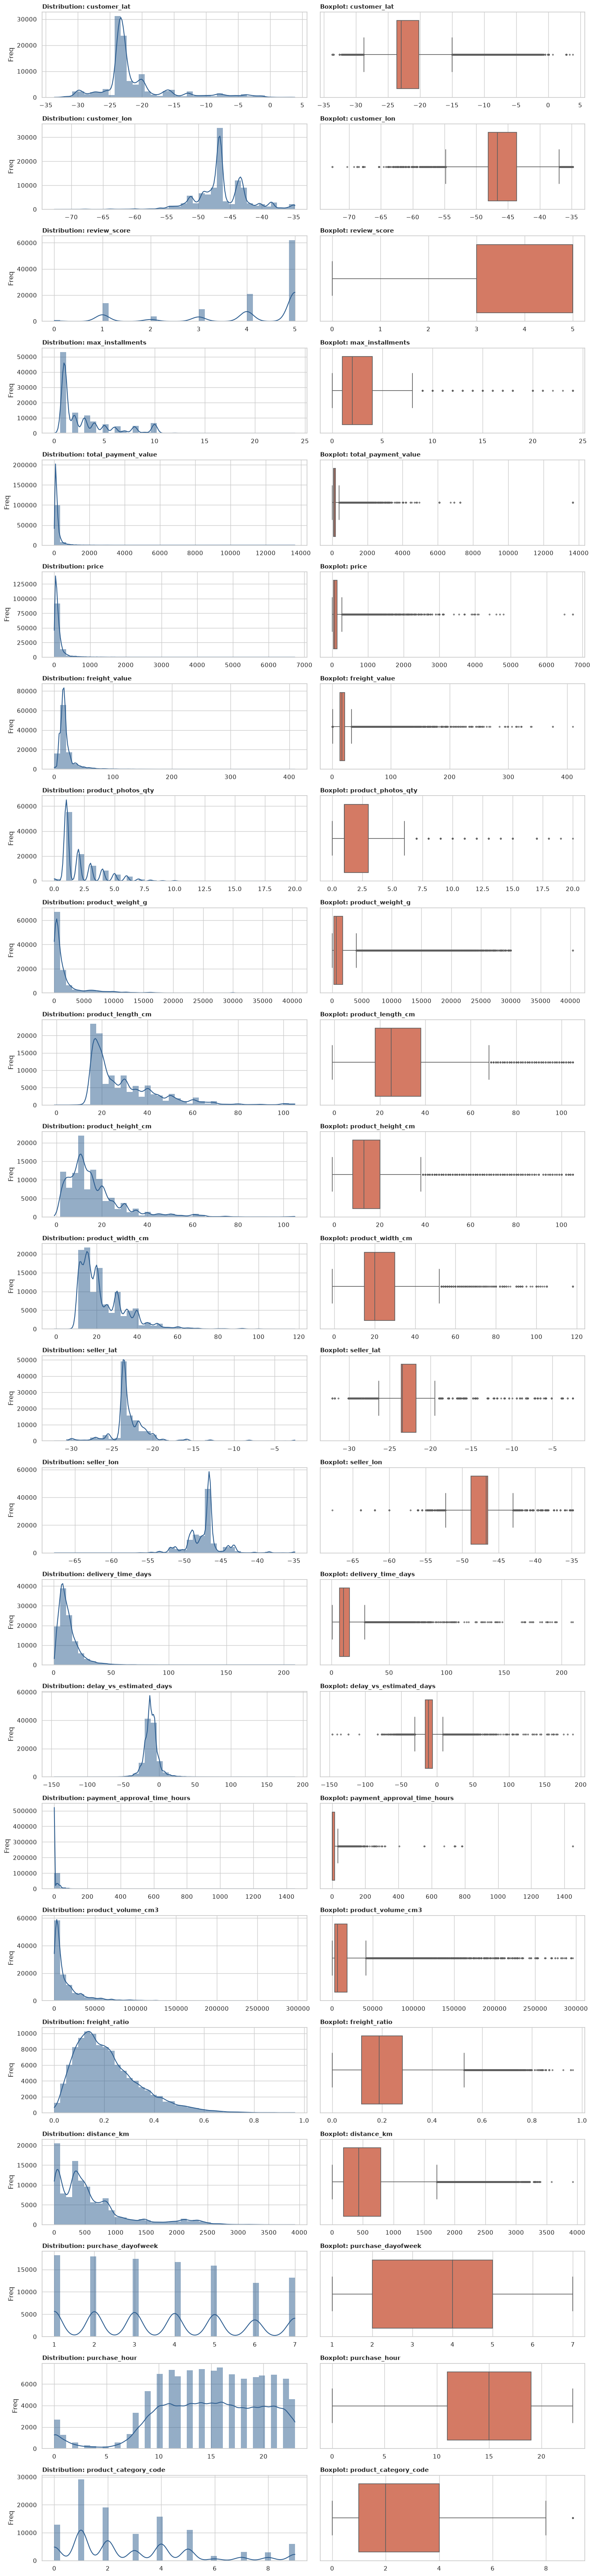

In [46]:
# Plots
n_vars = len(numeric_cols)
fig, axes = plt.subplots(n_vars, 2, figsize=(15, 2.8 * n_vars))

if n_vars == 1:
    axes = np.array([axes])

# Style
sns.set_theme(style="whitegrid")

for i, col in enumerate(numeric_cols):
    data = df_num[col].dropna()
    
    sns.histplot(
        data=data,
        kde=True,
        ax=axes[i, 0],
        color="#2b5c8f",
        bins=40,
        edgecolor="none"
    )
    axes[i, 0].set_title(f"Distribution: {col}", fontsize=11, fontweight="bold", loc="left")
    axes[i, 0].set_ylabel("Freq")
    axes[i, 0].set_xlabel("")
    
    # Boxplot
    sns.boxplot(
        x=data,
        ax=axes[i, 1],
        color="#e76f51",
        fliersize=2,
        linewidth=1.2
    )
    axes[i, 1].set_title(f"Boxplot: {col}", fontsize=11, fontweight="bold", loc="left")
    axes[i, 1].set_xlabel("")

plt.tight_layout()
plt.show()

In [47]:
cat_to_code

{'health_beauty_wellness': 0,
 'home_furniture_decor': 1,
 'tech_electronics_appliances': 2,
 'fashion_apparel_accessories': 3,
 'sports_leisure_toys': 4,
 'construction_tools_auto': 5,
 'books_media_entertainment': 6,
 'food_beverage_groceries': 7,
 'b2b_office_industry': 8,
 'other_specialty': 9}

In [48]:
skew_df = df.select([
    pl.col(col).skew().alias(f"{col}_skew")
    for col in numeric_cols
]).to_pandas().T.rename(columns={0: "skewness"})

# Ordenar por mayor asimetría a la derecha (right-skew)
skew_df["abs_skew"] = skew_df["skewness"].abs()
skew_df = skew_df.sort_values(by="abs_skew", ascending=False).drop(columns=["abs_skew"])

print("--- Asimetría de las variables (Valores > 1.0 sugieren log/RobustScaler) ---")
print(skew_df)

--- Asimetría de las variables (Valores > 1.0 sugieren log/RobustScaler) ---
                                   skewness
total_payment_value_skew          13.903121
payment_approval_time_hours_skew  11.834741
price_skew                         7.923957
freight_value_skew                 5.667067
product_volume_cm3_skew            4.075755
delivery_time_days_skew            3.839528
product_weight_g_skew              3.594754
seller_lat_skew                    2.768036
product_height_cm_skew             2.249197
delay_vs_estimated_days_skew       1.908657
product_photos_qty_skew            1.886944
product_length_cm_skew             1.757363
product_width_cm_skew              1.723551
distance_km_skew                   1.663986
customer_lat_skew                  1.615947
max_installments_skew              1.566611
review_score_skew                 -1.268302
freight_ratio_skew                 1.072035
product_category_code_skew         0.981364
purchase_hour_skew                -0.600002

In [49]:
target_vars = numeric_cols
# Convertir únicamente las columnas de interés a Pandas/NumPy
df_target = df.select(target_vars).to_pandas()

# Diccionario para almacenar los resultados de asimetría
results = []
best_transformations = {}

for col in target_vars:
    series = df_target[col].dropna().values
    original_skew = skew(series)
    
    # Squared (x^2
    sq_data = series ** 2
    sq_skew = skew(sq_data)
    
    # Cubed (x^3)
    cb_data = series ** 3
    cb_skew = skew(cb_data)
    
    # Box-Cox
    if np.any(series <= 0):
        shift = abs(np.min(series)) + 1e-5
        bc_data, _ = boxcox(series + shift)
    else:
        bc_data, _ = boxcox(series)
    bc_skew = skew(bc_data)
    
    # Yeo-Johnson
    yj_data, _ = yeojohnson(series)
    yj_skew = skew(yj_data)
    
    # Quantile Transformer
    qt = QuantileTransformer(output_distribution='normal', random_state=42, n_quantiles=min(1000, len(series)))
    qt_data = qt.fit_transform(series.reshape(-1, 1)).flatten()
    qt_skew = skew(qt_data)
    
    skews = {
        "variable": col,
        "original": original_skew,
        "squared": sq_skew,
        "cubed": cb_skew,
        "box_cox": bc_skew,
        "yeo_johnson": yj_skew,
        "quantile_norm": qt_skew
    }
    results.append(skews)
    
    transforms_eval = {
        "original": abs(original_skew),
        "squared": abs(sq_skew),
        "cubed": abs(cb_skew),
        "box_cox": abs(bc_skew),
        "yeo_johnson": abs(yj_skew),
        "quantile_norm": abs(qt_skew)
    }
    
    best_method = min(transforms_eval, key=transforms_eval.get)
    best_transformations[col] = {
        "best_method": best_method,
        "resulting_skew": skews[best_method]
    }

results_df = pd.DataFrame(results).set_index("variable")

In [71]:
results_df

,original,squared,cubed,box_cox,yeo_johnson,quantile_norm
variable,,,,,,
customer_lat,1.615947,-0.500172,-0.445548,0.101187,0.206844,0.027007
customer_lon,-0.000458,0.552539,-1.210892,0.131688,-0.060036,0.047032
review_score,-1.268302,-0.877250,-0.635134,-0.987131,-0.730591,-0.339835
max_installments,1.566611,4.373469,15.618891,-0.188905,0.321675,0.741726
total_payment_value,13.903121,93.678906,113.389344,-0.104715,-0.001516,0.046380
price,7.923957,49.990338,120.044654,-0.007840,-0.006469,0.003884
freight_value,5.667067,24.060863,51.297813,0.638336,-0.004352,-0.283705
product_photos_qty,1.886944,5.509477,16.598855,0.222159,0.017629,-1.259205
product_weight_g,3.594754,7.817283,11.885305,0.039098,0.041696,0.307463


In [89]:
SSE_skewness = results_df.apply(lambda x: sum( (0-x)**2 ) ).reset_index()
SSE_skewness.columns = ["method", "SSE"]
SSE_skewness

,method,SSE
0,original,510.779708
1,squared,38853.871288
2,cubed,80465.956196
3,box_cox,3.572011
4,yeo_johnson,2.108721
5,quantile_norm,4.423337


In [106]:
SSE_skewness.loc[SSE_skewness["SSE"].argmin(), "method"]

'yeo_johnson'

In [152]:
exclude_cols_corr = ["delivery_time_days", "delay_vs_estimated_days", "payment_approval_time_hours"]
numeric_cols_corr = [col for col in numeric_cols if col not in exclude_cols_corr]
X_corr = df.select(numeric_cols_corr).corr()
mask = np.triu(np.ones_like(X_corr))

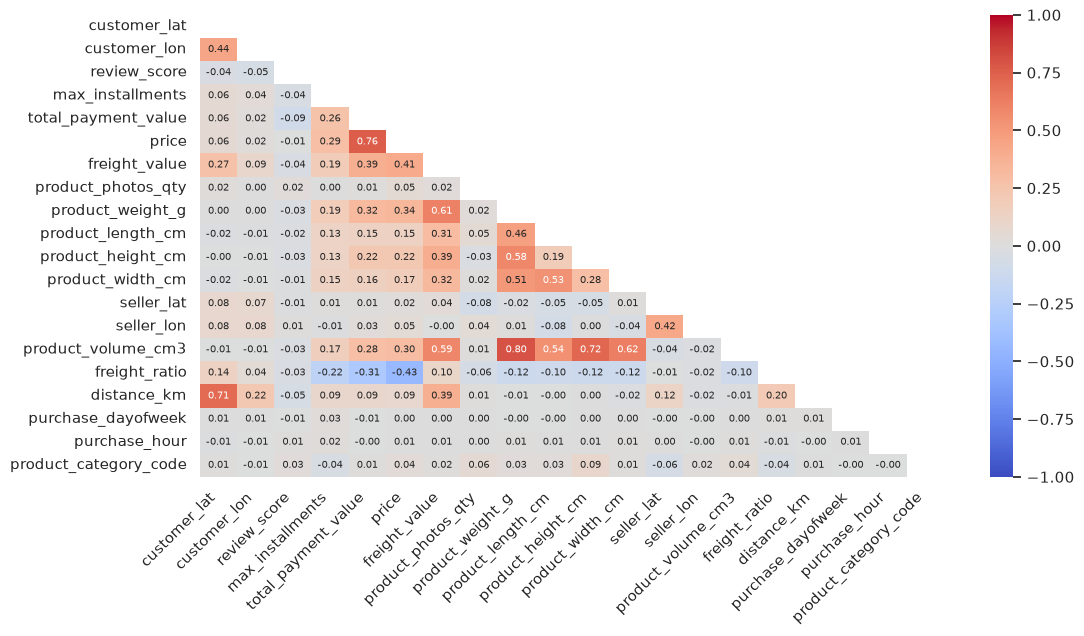

In [158]:
fig, ax = plt.subplots(figsize = (12,6))
sns.heatmap(X_corr,
            annot=True,
            fmt=".2f",
            xticklabels=numeric_cols_corr, 
            yticklabels=numeric_cols_corr,
            vmin=-1, vmax=1,
            cmap="coolwarm",
            ax=ax,
            annot_kws={"fontsize":7},
            mask=mask
           )
plt.grid(False)
ax.tick_params("x", rotation=45, rotation_mode="xtick")
plt.show()

---

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import PowerTransformer, StandardScaler

/home/quichoarch/Desktop/ml-e2e-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [52]:
# 2. Filtrar filas con entregas confirmadas y sin nulos en el subconjunto numérico
df_umap_subset = df.filter(
    pl.col("order_delivered_customer_date").is_not_null() &
    pl.col("order_purchase_timestamp").is_not_null()
).drop_nulls(subset=numeric_cols)

# Extraer la matriz a NumPy
X_raw = df_umap_subset.select(numeric_cols).to_numpy()

# 3. Transformación Yeo-Johnson + Escalamiento Estándar
pt = PowerTransformer(method="yeo-johnson", standardize=True)
X_trans = pt.fit_transform(X_raw)

# Inyección de jitter infinitesimal para prevenir degeneración en el grafo de k-NN
np.random.seed(42)
X_trans += np.random.normal(0, 1e-5, X_trans.shape)

# 4. Ajuste de UMAP (Inicialización PCA + Métrica Coseno)
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    init="pca",          # Evita advertencias espectrales y acelera la proyección
    random_state=42
)

In [53]:
embedding = reducer.fit_transform(X_trans)

/home/quichoarch/Desktop/ml-e2e-project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [62]:
# 5. Construcción del DataFrame para visualización
df_plot = df_umap_subset.select([
    "review_score", 
    "delay_vs_estimated_days",
    "distance_km"
]).with_columns([
    pl.Series("umap_1", embedding[:, 0]),
    pl.Series("umap_2", embedding[:, 1]),
]).to_pandas()

# Reordenar para evitar overplotting del review_score
df_plot_sorted = df_plot.sort_values(by="review_score", ascending=True)

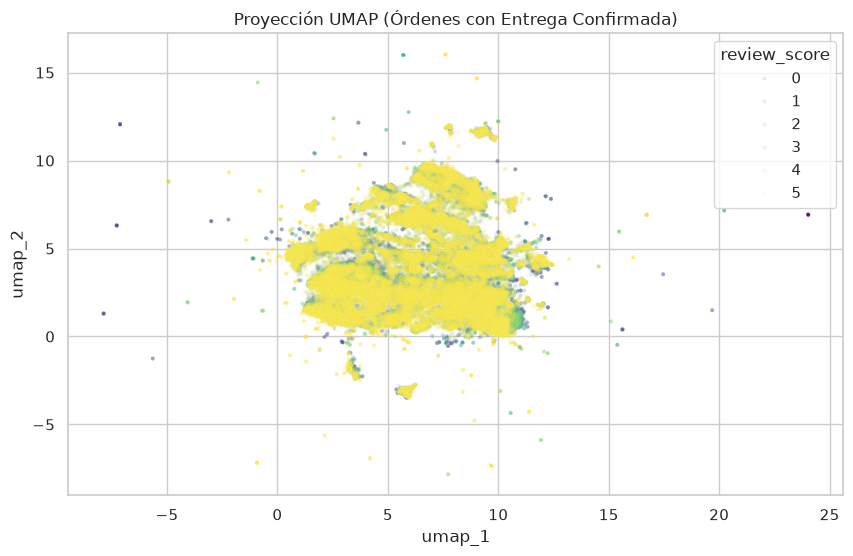

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot_sorted,
    x="umap_1",
    y="umap_2",
    hue="review_score",
    palette="viridis",
    alpha=0.1,
    s=8
)
plt.title("Proyección UMAP (Órdenes con Entrega Confirmada)")
plt.show()

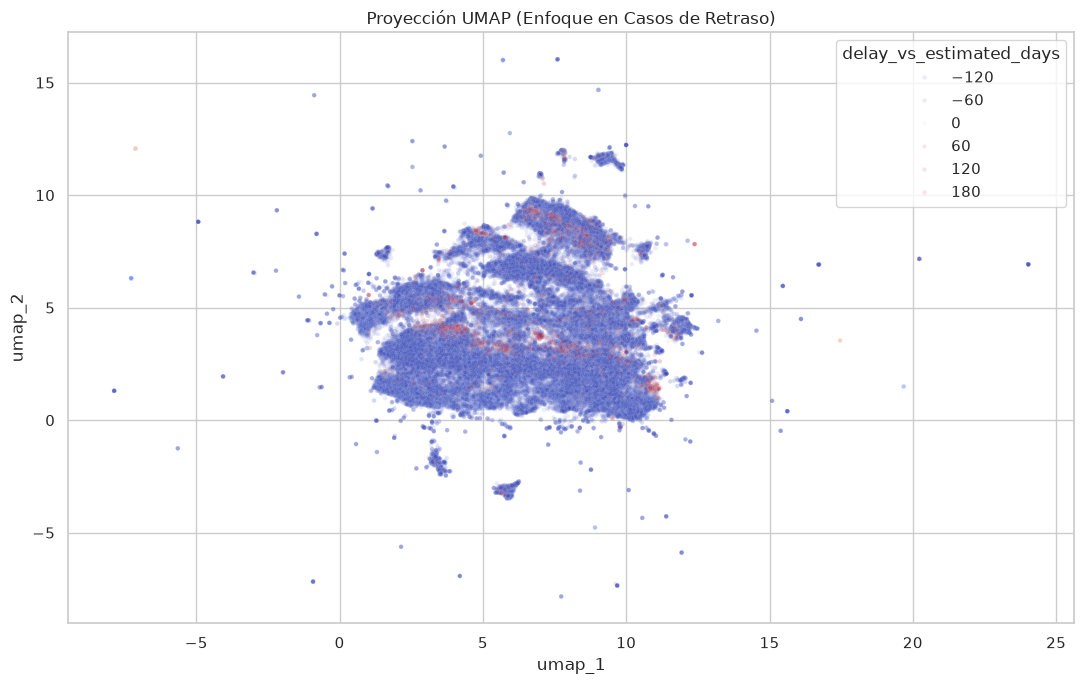

In [69]:
df_normal = df_plot_sorted[df_plot_sorted["delay_vs_estimated_days"] <= 5]
df_delays = df_plot_sorted[df_plot_sorted["delay_vs_estimated_days"] > 5]

df_stratified_sample = pd.concat([df_normal, df_delays]).sample(frac=1.0) # Shuffle

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_stratified_sample,
    x="umap_1",
    y="umap_2",
    hue="delay_vs_estimated_days",
    palette="coolwarm",
    hue_norm=(-5, 10),
    alpha=0.1,
    s=10
)
plt.title("Proyección UMAP (Enfoque en Casos de Retraso)")
plt.tight_layout()
plt.show()

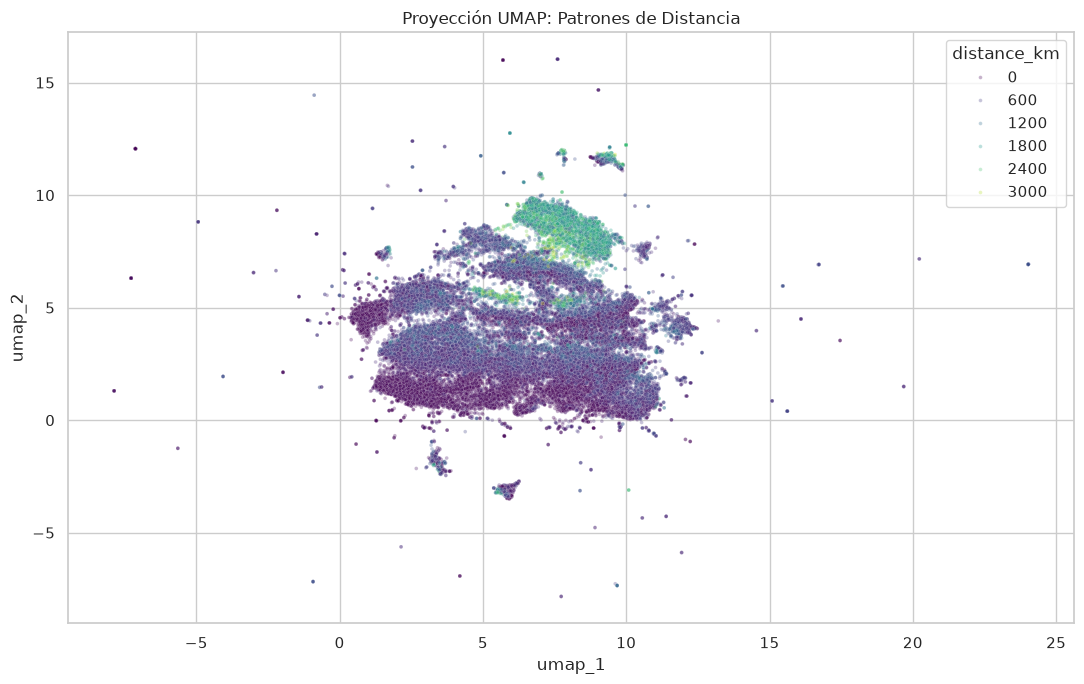

In [70]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_plot_sample,
    x="umap_1",
    y="umap_2",
    hue="distance_km",
    palette="viridis",
    alpha=0.3,
    s=7
)

plt.title("Proyección UMAP: Patrones de Distancia")
plt.tight_layout()
plt.show()